<a href="https://colab.research.google.com/github/anhquan-truong/PM520/blob/main/Lab_13_HMC_AnhQuanTRUONG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Don't Stop Me Now, or: Hamiltonian Monte Carlo

Most MCMC samplers (e.g. random‑walk Metropolis) suffer from slow exploration in high‑dimensional spaces. [Hamiltonian Monte Carlo](https://en.wikipedia.org/wiki/Hamiltonian_Monte_Carlo) augments your target density
$$
\pi(\theta)\propto \exp\bigl(-U(\theta)\bigr)
$$
U is the energy function.
with an auxiliary “momentum” variable $p$ to explore with (approximately) energy‑conserving trajectories, reducing random‑walk behaviour.


## Hamiltonian dynamics

Define
$$
H(\theta,p) \;=\; U(\theta)\;+\;K(p),
$$
where
- $U(\theta)=-\log\pi(\theta)$ (“potential energy”),  
- $K(p)=\tfrac12\,p^T M^{-1}p$ (“kinetic energy”), and $M$ is a chosen mass matrix (often identity).

Hamilton’s equations give continuous dynamics:
$$
\frac{d\theta}{dt} = \frac{\partial H}{\partial p} = M^{-1}p,
\qquad
\frac{dp}{dt} = -\frac{\partial H}{\partial \theta} = -\nabla U(\theta).
$$
These dynamics are **volume‑preserving** and conserve $H$, so if we could simulate them exactly over time $T$, the joint density
$\exp(-H(\theta,p))$
would be invariant.

![HMC](https://upload.wikimedia.org/wikipedia/commons/f/fa/Hamiltonian_Monte_Carlo.gif "hmc")


## Symplectic integrator: the leapfrog method

We cannot solve Hamilton’s equations in closed form in general, so we use a symplectic (volume‑preserving, reversible) discretization.  With step size $\varepsilon$ and letting $\nabla U(\theta)$ denote the gradient:

1. Half‑step momentum:
   $$
   p_{t + \frac12} \;=\; p_t \;-\;\tfrac{\varepsilon}{2}\,\nabla U(\theta_t),
   $$
2. Full‑step position:
   $$
   \theta_{t+1} \;=\; \theta_t \;+\;\varepsilon\,M^{-1}p_{t + \frac12},
   $$
3. Half‑step momentum:
   $$
   p_{t+1} \;=\; p_{t + \frac12} \;-\;\tfrac{\varepsilon}{2}\,\nabla U(\theta_{t+1}).
   $$

This integrator is reversible and approximately conserves $H$ up to $O(\varepsilon^2)$.

## The HMC algorithm

Putting it all together, one HMC iteration from current state $\theta$ is:

1. **Sample** a fresh momentum  
   $\displaystyle p\sim\mathcal N(0,\,M)$.
2. **Simulate** $L$ leapfrog steps of size $\varepsilon$ to propose $(\theta^*, p^*)$.
3. **Negate** momentum (makes proposal reversible): $p^*\leftarrow -p^*$.
4. **Metropolis accept/reject** with probability
   $$
   \alpha = \min\!\Bigl(1,\;\exp\bigl[-H(\theta^*,p^*) + H(\theta,p)\bigr]\Bigr).
   $$
   If accepted, set $\theta\leftarrow\theta^*$, else keep the old $\theta$.
5. **Discard** $p$ and repeat.

Key tuning parameters:
- Step size $\varepsilon$ (too large → low acceptance;
  too small → slow exploration).
- Number of steps $L$ (longer trajectories explore farther but cost more).




## Implementing HMC in JAX via BlackJAX

We’ll demonstrate on a two‑dimensional “banana” target,
$$
\pi(x,y)\propto
\exp\!\Bigl[-\bigl(x^2/2 + (y + 0.03\,x^2 - 3)^2/2\bigr)\Bigr].
$$

In [4]:
!pip install blackjax

In [5]:
import jax
import jax.numpy as jnp
import blackjax

# 1. Define log‑density and gradient
def logprob(z):
    x, y = z[..., 0], z[..., 1]
    return -0.5*(x**2 + (y + 0.03*x**2 - 3)**2)

# 2. Set up HMC kernel (identity mass)
step_size = 0.001
num_steps = 5000
Minv = jnp.array([[1.0, 0.0], [0.0, 1.0]])
hmc = blackjax.hmc(logprob, step_size, Minv, num_steps)

# 3. Initialize
key = jax.random.PRNGKey(10)
init_position = jnp.array([10.0, 10.0])
state = hmc.init(init_position)

# 4. Run a chain
@jax.jit
def one_step(state, key):
    key, subkey = jax.random.split(key)
    state, info = hmc.step(subkey, state)
    return state, (state.position, info.is_accepted)

num_samples = 10_000
keys = jax.random.split(key, num_samples)
states, (positions, accept) = jax.lax.scan(one_step, state, keys)

positions = jnp.stack(positions)  # shape (num_samples, 2)
accept_rate = accept.mean()

print("Acceptance rate:", accept_rate)
import matplotlib.pyplot as plt

# Trace plots
fig, axes = plt.subplots(2,1, figsize=(6,4), sharex=True)
axes[0].plot(positions[:,0]); axes[0].set_ylabel("x")
axes[1].plot(positions[:,1]); axes[1].set_ylabel("y")
axes[1].set_xlabel("Iteration")

# Scatter of samples
plt.figure(figsize=(4,4))
plt.scatter(positions[:,0], positions[:,1], s=5, alpha=0.5)
plt.title("Joint scatter of HMC samples")
plt.xlabel("x"); plt.ylabel("y")
plt.tight_layout()

JaxRuntimeError: INVALID_ARGUMENT: Unexpected PJRT_FFI_UserData_Add_Args size: expected 48, got 40. The plugin is likely built with a later version than the framework. This plugin is built with PJRT API version 0.76.

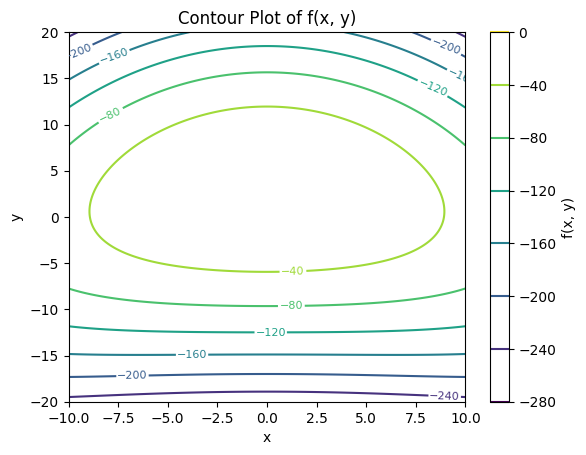

In [33]:
import matplotlib.pyplot as plt

def logprob(x, y):
    return -0.5*(x**2 + (y + 0.03*x**2 - 3)**2)

x = jnp.linspace(-10, 10, 1_000)
y = jnp.linspace(-20, 20, 1_000)
x, y = jnp.meshgrid(x, y)
Z = logprob(x, y)
# Plot the contour
plt.figure()
CS = plt.contour(x, y, Z)  # default contour
plt.clabel(CS, inline=True, fontsize=8)
plt.title('Contour Plot of f(x, y)')
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar(label='f(x, y)')
plt.show()

## 7 – Exercises

1. **Tuning step size.** Try $\varepsilon=0.05,0.2$. How does the acceptance rate and effective sample size change?
2. **Changing trajectory length.** Fix $\varepsilon=0.1$. Try $L=5,50$. What is the trade‑off?
3. **Mass matrix.** Implement a diagonal mass matrix $M=\mathrm{diag}(1,\,10)$. How does sampling improve?
4. **Apply to logistic regression.** Replace the banana target with a Bayesian logistic‐regression posterior on a real or synthetic dataset. Compare to a random‑walk Metropolis baseline.
5. **Extension (NUTS).** Study the No‑U‑Turn Sampler: how does it choose $L$ automatically? Try BlackJAX’s `blackjax.nuts`.


Acceptance rate: 0.9939744


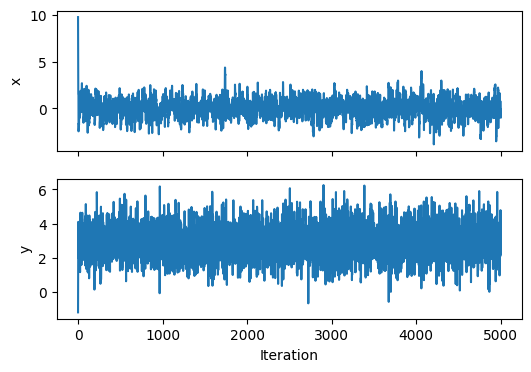

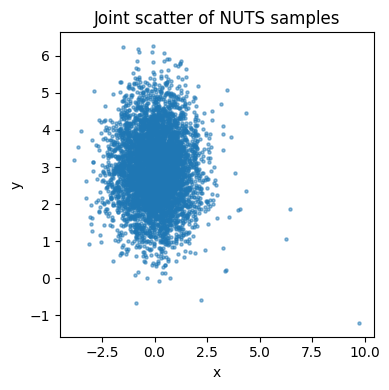

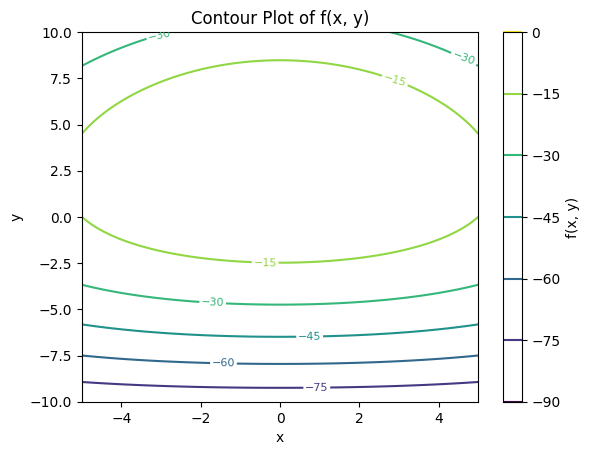

In [59]:
import jax

# 1. Define log‑density and gradient
def logprob(z):
    x, y = z[..., 0], z[..., 1]
    return -0.5*(x**2 + (y + 0.03*x**2 - 3)**2)

# 2. Set up HMC kernel (identity mass)
step_size = 0.1
num_steps = 1000
Minv = jnp.array([[1.0, 0.5], [0.5, 10.0]])

nuts = blackjax.nuts(logprob, step_size, Minv)

# 3. Initialize
key = jax.random.PRNGKey(10)
init_position = jnp.array([10.0, -1.0])
state = nuts.init(init_position)

# 4. Run a chain
@jax.jit
def one_step(state, key):
    key, subkey = jax.random.split(key)
    state, info = nuts.step(subkey, state)
    return state, (state.position, info.acceptance_rate)

num_samples = 5_000
keys = jax.random.split(key, num_samples)
states, (positions, accept_rate) = jax.lax.scan(one_step, state, keys)

positions = jnp.stack(positions)  # shape (num_samples, 2)
accept_rate = accept_rate.mean()

print("Acceptance rate:", accept_rate)
import matplotlib.pyplot as plt

# Trace plots
fig, axes = plt.subplots(2,1, figsize=(6,4), sharex=True)
axes[0].plot(positions[:,0]); axes[0].set_ylabel("x")
axes[1].plot(positions[:,1]); axes[1].set_ylabel("y")
axes[1].set_xlabel("Iteration")

# Scatter of samples
plt.figure(figsize=(4,4))
plt.scatter(positions[:,0], positions[:,1], s=5, alpha=0.5)
plt.title("Joint scatter of NUTS samples")
plt.xlabel("x"); plt.ylabel("y")
plt.tight_layout()

def logprob(x, y):
    return -0.5*(x**2 + (y + 0.03*x**2 - 3)**2)

x = jnp.linspace(-5, 5, 1_000)
y = jnp.linspace(-10, 10, 1_000)
x, y = jnp.meshgrid(x, y)
Z = logprob(x, y)
# Plot the contour
plt.figure()
CS = plt.contour(x, y, Z)  # default contour
plt.clabel(CS, inline=True, fontsize=8)
plt.title('Contour Plot of f(x, y)')
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar(label='f(x, y)')
plt.show()

## Bayesian Logistic Regression

[todo]



In [2]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
import jax.nn as nn
import jax.random as rdm
import jax.scipy.stats as stats
import blackjax

from sklearn.datasets import make_biclusters


seed = 0
rng_key = rdm.key(seed)

# generate data
N, P = 500, 2
X, rows, cols = make_biclusters(
    (N, P), 2, noise=0.6, random_state=314, minval=-3, maxval=3
)
y = rows[0] * 1.0  # y[i] = whether point i belongs to cluster 1
colors = ["tab:red" if el else "tab:blue" for el in rows[0]]

# 1. set up density
prior_var_b = 0.1
def logprob(beta):
  log_prior = jnp.sum(stats.norm.logpdf(beta, scale=jnp.sqrt(prior_var_b)))
  pi = nn.sigmoid(X @ beta)
  log_like = jnp.sum(stats.bernoulli.logpmf(y, pi))
  return log_like + log_prior

# 2. Set up HMC kernel (identity mass)
step_size = 0.01
num_steps = 500
Minv = jnp.eye(P) * jnp.reciprocal(prior_var_b)

nuts = blackjax.nuts(logprob, step_size, Minv)

# 3. Initialize

init_position = jnp.zeros((P,))
state = nuts.init(init_position)

# 4. Run a chain
@jax.jit
def one_step(state, key):
    key, subkey = jax.random.split(key)
    state, info = nuts.step(subkey, state)
    return state, (state.position, info.acceptance_rate)

num_samples = 5_000
keys = jax.random.split(key, num_samples)
states, (positions, accept_rate) = jax.lax.scan(one_step, state, keys)

positions = jnp.stack(positions)  # shape (num_samples, 2)
accept_rate = accept_rate.mean()

print("Acceptance rate:", accept_rate)

fig, ax = plt.subplots(1, 2, figsize=(12, 2))
for j, axi in enumerate(ax):
    axi.plot(positions[..., j])
    axi.set_title(f"$beta_{j}$")
plt.show()

# Create a meshgrid
xmin, ymin = X.min(axis=0) - 0.1
xmax, ymax = X.max(axis=0) + 0.1
step = 0.1
Xspace = jnp.mgrid[xmin:xmax:step, ymin:ymax:step]
_, nx, ny = Xspace.shape

# Compute the average probability to belong to the first cluster at each point on the meshgrid
print(Xspace.shape)
print(positions.shape)
Z_mcmc = nn.sigmoid(jnp.einsum("mij,sm->sij", Xspace, positions))
Z_mcmc = Z_mcmc.mean(axis=0)
plt.contourf(*Xspace, Z_mcmc)
plt.scatter(*X.T, c=colors)
plt.xlabel(r"$X_0$")
plt.ylabel(r"$X_1$");

/usr/local/lib/python3.12/dist-packages/jaxlib/plugin_support.py:91: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.7.2 is installed, but it is not compatible with the installed jaxlib version 0.9.2, so it will not be used.
  warnings.warn(
ERROR:jax._src.xla_bridge:Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jax/_src/xla_bridge.py", line 487, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/usr/local/lib/python3.12/dist-packages/jax_plugins/xla_cuda12/__init__.py", line 348, in initialize
    xla_client.register_custom_type_id_handler(
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: module 'jaxlib.xla_client' has no attribute 'register_custom_type_id_handler'. Did you mean: 'register_custom_type_handler'?


JaxRuntimeError: INVALID_ARGUMENT: Unexpected PJRT_FFI_UserData_Add_Args size: expected 48, got 40. The plugin is likely built with a later version than the framework. This plugin is built with PJRT API version 0.76.

Multiple chain with VMAP

In [3]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
import jax.nn as nn
import jax.random as rdm
import jax.scipy.stats as stats
import blackjax
import multiprocessing

from sklearn.datasets import make_biclusters


seed = 0
rng_key = rdm.key(seed)

# generate data
N, P = 500, 2
X, rows, cols = make_biclusters(
    (N, P), 2, noise=0.6, random_state=314, minval=-3, maxval=3
)
y = rows[0] * 1.0  # y[i] = whether point i belongs to cluster 1
colors = ["tab:red" if el else "tab:blue" for el in rows[0]]

# 1. set up density
prior_var_b = 0.1
def logprob(beta):
  log_prior = jnp.sum(stats.norm.logpdf(beta, scale=jnp.sqrt(prior_var_b)))
  pi = nn.sigmoid(X @ beta)
  log_like = jnp.sum(stats.bernoulli.logpmf(y, pi))
  return log_like + log_prior

# 2. Set up HMC kernel (identity mass)
step_size = 0.01
num_steps = 500
num_chains = multiprocessing.cpu_count()
Minv = jnp.eye(P) * jnp.reciprocal(prior_var_b)

nuts = blackjax.nuts(logprob, step_size, Minv)

# 3. Initialize
initial_positions = jnp.zeros(shape = (num_chains,P))
initial_states = jax.vmap(nuts.init)(initial_positions)

# 4. Run a chain

def inference_loop_multiple_chains(
    rng_key, kernel, initial_state, num_samples, num_chains
):

    @jax.jit
    def one_step(states, rng_key):
        keys = jax.random.split(rng_key, num_chains)
        new_states, info = jax.vmap(kernel)(keys, states)
        # Return new_states as the carry for the next iteration
        # Return a tuple (new_states.position, info.acceptance_rate) to be collected by scan
        return new_states, (new_states.position, info.acceptance_rate)

    # The scan function iterates for num_samples and accumulates (position, acceptance_rate)
    keys = jax.random.split(rng_key, num_samples)
    final_carry, (positions, acceptance_rates) = jax.lax.scan(one_step, initial_state, keys)

    return positions, acceptance_rates


num_samples = 5_000

rng_key, sample_key = jax.random.split(rng_key)

# Unpack the results from inference_loop_multiple_chains correctly
positions, acceptance_rates_per_step_chain = inference_loop_multiple_chains(
    sample_key, nuts.step, initial_states, num_samples, num_chains
)

_ = positions.block_until_ready()

# Calculate the mean acceptance rate across all chains and all samples
mean_acceptance_rate = acceptance_rates_per_step_chain.mean()

print("Acceptance rate:", mean_acceptance_rate)
print(f"number of chains: {num_chains}")

fig, ax = plt.subplots(1, P, figsize=(12, 2))
# Plot trace for each parameter for all chains
for j in range(P):
    for chain_idx in range(num_chains):
        ax[j].plot(positions[:, chain_idx, j], alpha=0.7)
    ax[j].set_title(f"$beta_{j}$ (All Chains)")
plt.show()

# Scatter of samples (flattened from all chains)
# Reshape positions from (num_samples, num_chains, P) to (num_samples * num_chains, P)
flattened_positions = positions.reshape(-1, P)

plt.figure(figsize=(4,4))
plt.scatter(flattened_positions[:,0], flattened_positions[:,1], s=5, alpha=0.5)
plt.title("Joint scatter of NUTS samples (all chains)")
plt.xlabel("x"); plt.ylabel("y")
plt.tight_layout()

# Create a meshgrid
xmin, ymin = X.min(axis=0) - 0.1
xmax, ymax = X.max(axis=0) + 0.1
step = 0.1
Xspace = jnp.mgrid[xmin:xmax:step, ymin:ymax:step]
_, nx, ny = Xspace.shape

# Compute the average probability to belong to the first cluster at each point on the meshgrid
print(Xspace.shape)
print(positions.shape)
Z_mcmc = nn.sigmoid(jnp.einsum("mij,sm->sij", Xspace, flattened_positions))
Z_mcmc = Z_mcmc.mean(axis=0)
plt.contourf(*Xspace, Z_mcmc)
plt.scatter(*X.T, c=colors)
plt.xlabel(r"$X_0$")
plt.ylabel(r"$X_1$");

JaxRuntimeError: INVALID_ARGUMENT: Unexpected PJRT_FFI_UserData_Add_Args size: expected 48, got 40. The plugin is likely built with a later version than the framework. This plugin is built with PJRT API version 0.76.

In [90]:
import arviz as az
import xarray as xr

# ArviZ expects dimensions (num_chains, num_samples, num_params)
# Our 'positions' array is currently (num_samples, num_chains, num_params)
# So, we need to transpose it.
posterior_samples = jnp.swapaxes(positions, 0, 1)

# ArviZ expects sample_stats to be (num_chains, num_samples)
acceptance_rate_for_arviz = jnp.swapaxes(acceptance_rates_per_step_chain, 0, 1)

# Create an InferenceData object using az.from_dict
idata = az.from_dict(
    posterior={"beta": posterior_samples},
    sample_stats={"acceptance_rate": acceptance_rate_for_arviz}
)

print("ArviZ InferenceData object created:")
display(idata)

ArviZ InferenceData object created:


Inference data with groups:
	> posterior
	> sample_stats

Now that the samples are in an `InferenceData` object, you can easily use ArviZ for various diagnostics. For example, let's look at the summary statistics and trace plots generated by ArviZ.

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta[0],0.661,0.136,0.398,0.907,0.002,0.002,3557.0,3975.0,1.0
beta[1],0.678,0.133,0.426,0.923,0.002,0.002,3435.0,4469.0,1.0


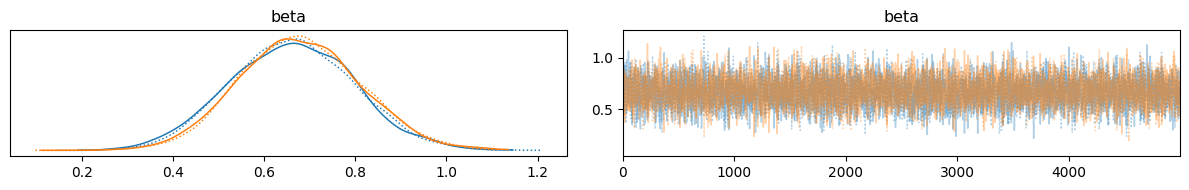

In [91]:
# Print summary statistics (including R-hat and ESS)
display(az.summary(idata))

# Plot traces and posterior distributions using ArviZ
az.plot_trace(idata)
plt.tight_layout()
plt.show()

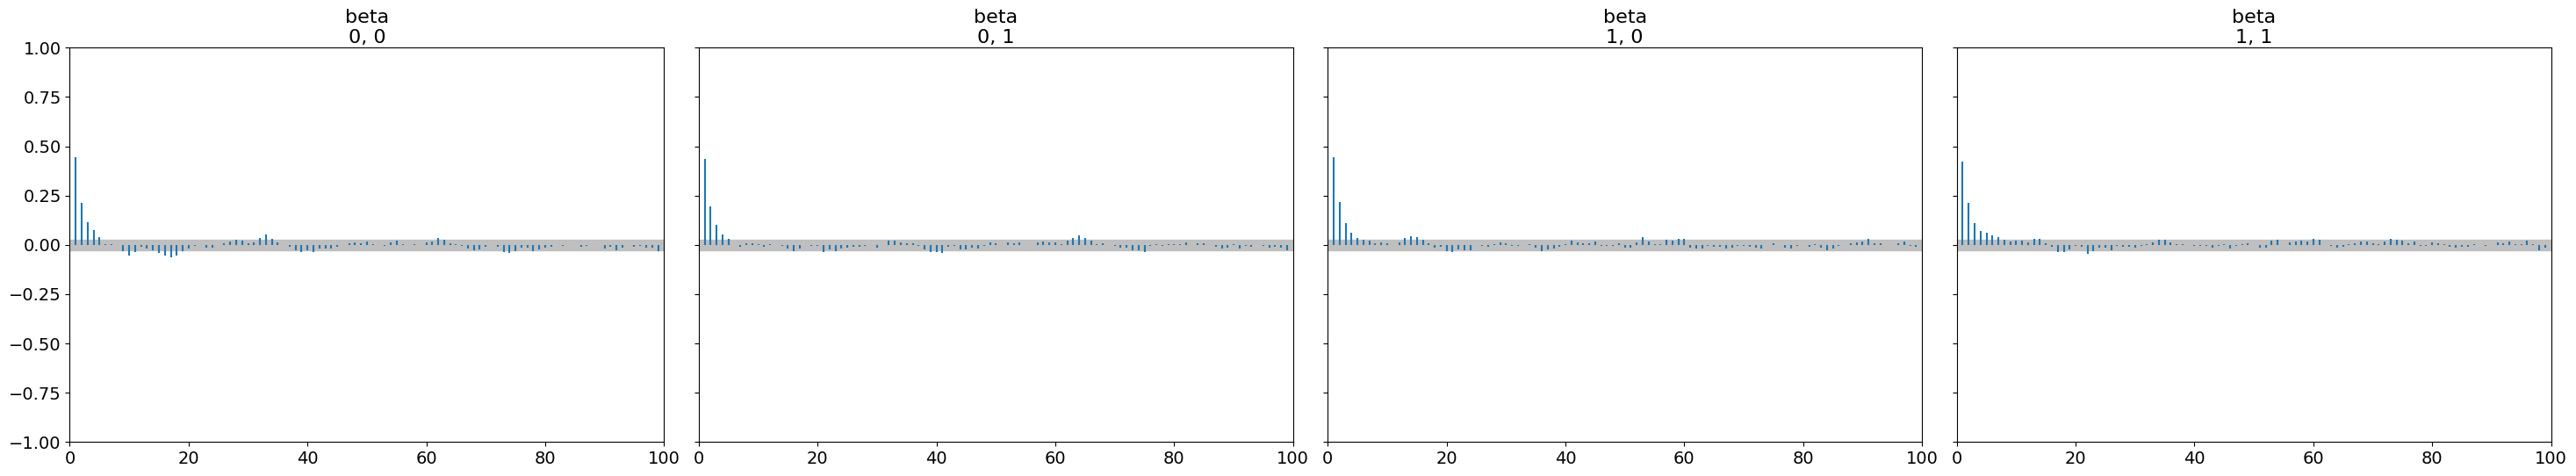

In [92]:
# Plot autocorrelation
az.plot_autocorr(idata, max_lag=100)
plt.tight_layout()
plt.show()